1. Опишите теоретическую модель линейной и логистической регрессии.
2. Напишите следующий год: сгенерируйте данные в виде набора точек по нескольким кластерам; выполните кластеризацию; визуализируйте результат.
3. Опишите метрику для проверки качества алгоритмов классификации.

# Логистическая регрессия

Проблема: классифицировать данные, в которых объекты с одинаковыми признаками могут принадлежать различным классам

**Пример:**

| Доход  | Наличие жилья | Наличие работы | Число детей | Возврат кредита |
|--------|---------------|----------------|-------------|-----------------|
| 10 000 | 1             | 1              | 2           | 1               |
| 10 000 | 1             | 1              | 2           | 0               |
| 10 000 | 1             | 1              | 2           | 0               |
| 10 000 | 1             | 1              | 2           | 1               |
| 10 000 | 1             | 1              | 2           | 0               |
| 10 000 | 1             | 1              | 2           | 1               |
| 15 000 | 1             | 0              | 3           | 0               |
| 15 000 | 1             | 0              | 3           | 0               |
| 15 000 | 1             | 0              | 3           | 0               |
| 15 000 | 1             | 0              | 3           | 0               |
| 15 000 | 1             | 0              | 3           | 0               |
| 15 000 | 1             | 0              | 3           | 1               |

Мы хотим создать линейную модель $a(w, X)$, которая будет возвращать, значения в диапазоне $[0;1]$, интерпретируемые как вероятности

Как перевести линию в диапазон $[0;1]$?

- Использование экспоненциальной функции сделает результат неотрицательным
- Чем дальше точка от границы раздела классов, тем больше уверенность классификатора

Если выбрать следующую функцию в качестве модели: $\sigma(z) =  \dfrac{1}{1 + e^{-z}}, \quad z = (w_i, x_i) + b$, то для объектов класса 1 $e^{-z}$ будет почти $0$ и результат будет близок к $1$. С другой стороны, если взять объекты класса $0$ то $e{-z}$ будет стремится к бесконечности и результат будет стремится к $0$. То есть наша модель предсказывает вероятность принадлежности объекта к классу $1$

Предполагая наши данные статистически независимыми, мы можем ввести функцию правдоподобия:

$$
L(X, w) = \prod_i p(x_i)^{y_i} (1 - p(x_i))^{1-y_i}
$$

Выполним монотонное преобразование:

$$
\ln L(X, w) = \sum_i \ln p(x_i)^{y_i} + \ln (1 - p(x_i))^{1-y_i} = \sum_i y_i \ln p(x_i) + (1 - y_i) \ln (1 - p(x_i))
$$

Используя метод максимального правдоподобия, будет решать задачу минимизации минус логарифма правдоподобия:

$$
\ln L(X, w) \longrightarrow max,
\\
-\ln L(X, w) \longrightarrow min
\\
-\sum_i y_i \ln \sigma(x_i) + (1 - y_i) \ln (1 - \sigma(x_i)) \longrightarrow min
$$

Решение данной задачи делаем методом градиентного спуска:

$$
\sigma^{\prime}(z) = \sigma(z) (1 - \sigma(z))
\\
\nabla_w L=\sum_i​(\sigma(w^T x_i​)−y_i​)x_i​.
$$

Вычисление вероятности принадлежности классу $y_i=1$: $\sigma(z) =  \dfrac{1}{1 + e^{-z}}, \quad z = (w_i, x_i) + b$,
Вычисление вероятности принадлежности классу $y_i=0$: $1 - \sigma(z)$

# Кластеризация

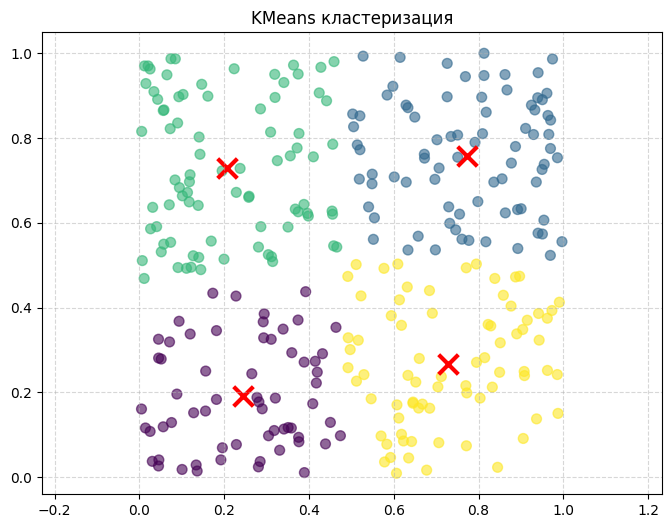

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

np.random.seed(42)
n_points = 300
X = np.random.rand(n_points, 2)

kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(X)
centroids = kmeans.cluster_centers_

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', alpha=0.6, s=50)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='x', s=200, linewidths=3)
plt.title('KMeans кластеризация')
plt.grid(True, linestyle='--', alpha=0.5)
plt.axis('equal')
plt.show()

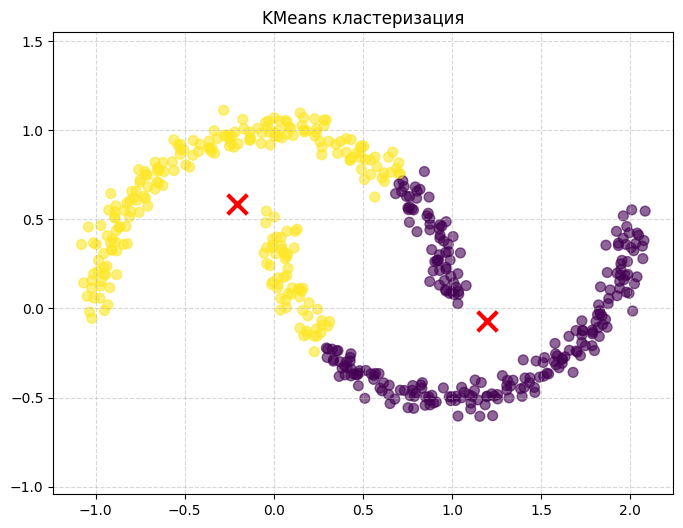

In [48]:
X, _ = make_moons(n_samples=500, noise=0.05, random_state=42)

kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(X)
centroids = kmeans.cluster_centers_

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', alpha=0.6, s=50)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='x', s=200, linewidths=3)
plt.title('KMeans кластеризация')
plt.grid(True, linestyle='--', alpha=0.5)
plt.axis('equal')
plt.show()

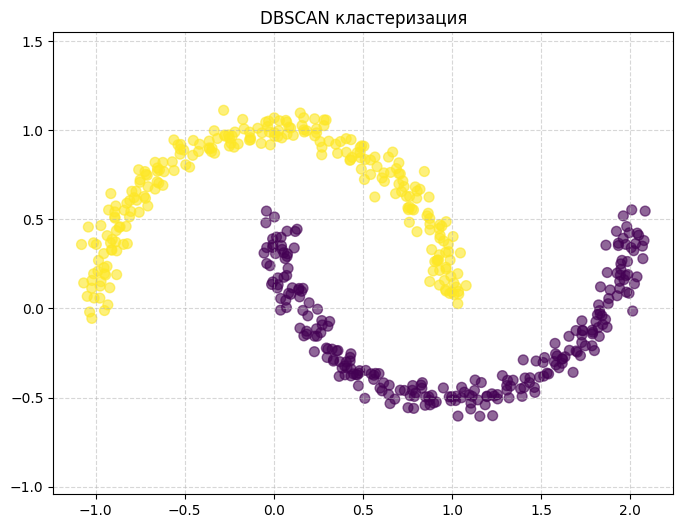

In [49]:
X, _ = make_moons(n_samples=500, noise=0.05, random_state=42)

dbscan = DBSCAN(eps=0.2, min_samples=5)
labels = dbscan.fit_predict(X)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', alpha=0.6, s=50)
plt.title('DBSCAN кластеризация')
plt.grid(True, linestyle='--', alpha=0.5)
plt.axis('equal')
plt.show()


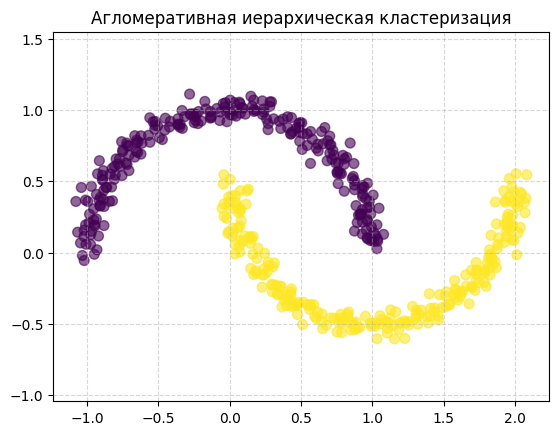

In [52]:
X, _ = make_moons(n_samples=500, noise=0.05, random_state=42)

# linkage: 'ward', 'complete', 'average', 'single'
method = 'single'

agglo = AgglomerativeClustering(n_clusters=2, linkage=method)
labels_agglo = agglo.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels_agglo, cmap='viridis', alpha=0.6, s=50)
plt.title('Агломеративная иерархическая кластеризация')
plt.grid(True, linestyle='--', alpha=0.5)
plt.axis('equal')

plt.show()

linked = linkage(X, method=method)

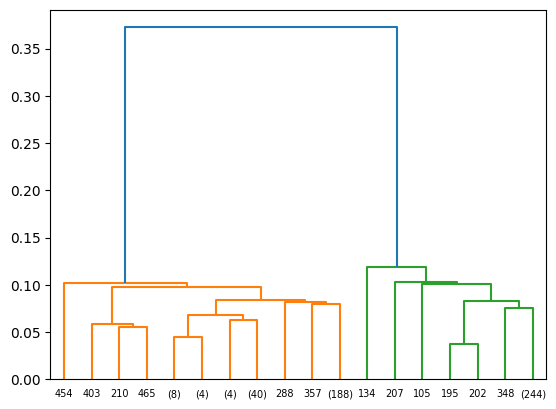

In [66]:
dendrogram(
    linked,
    truncate_mode='level',  # или 'lastp' — чтобы ограничить глубину
    p=5,                   # показать только последние 10 уровней слияния
    leaf_font_size=7,
)
plt.show()

# Метрики качества для задач бинарной классификации

$N$ $-$ число объектов

$TP$ $-$ Число верных положительных предсказаний

$FP$ $-$ Число ложноположительных предсказаний

$TN$ $-$ Число верных отрицательных предсказаний

$FN$ $-$ Число ложноотрицательных предсказаний

$$
\begin{aligned}
accuracy &= \dfrac{TP + TN}{N},
\\
precision &= \dfrac{TP}{TP + FP},
\\
recall &= \dfrac{TP}{TP + FN},
\\
F_1 &= \dfrac{2 \, precision \cdot recall}{precision + recall},
\\
F_{\beta} &= \dfrac{(1 + \beta^2) \, precision \cdot recall}{\beta^2 \cdot precision + recall},
\\
TPR(t) &= \dfrac{TP(t)}{TP(t) + FN(t)},
\\
FPR(t) &= \dfrac{FP(t)}{TN(t) + FP(t)}
\\
AUC &= S_{ROC}
\\
Gini &= 2(AUC - 0.5) = 2AUC - 1
\end{aligned}
$$

<p align="center">
  <img src="https://proproprogs.ru/htm/ml/files/ml-metriki-kachestva-ranzhirovaniya-roc-krivaya.files/image026.png" alt="ROC">
</p>

<p align="center">
  <img src="https://proproprogs.ru/htm/ml/files/ml-metriki-kachestva-ranzhirovaniya-roc-krivaya.files/image030.png" alt="Gini">
</p>

<p align="center">
  <img src="https://i0.wp.com/neptune.ai/wp-content/uploads/2022/10/prec_rec_curve.png?ssl=1" alt="Gini">
</p>